## Step 1 — Import Libraries
---

In [16]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from IPython.display import display
from matplotlib.ticker import FuncFormatter

# Step 1a: Load the dataset
file_path = r'../data_raw/online_retail_uk.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')     # handles special characters

# Step 1b: Inspect the dataset
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head()) 

Dataset shape: (536350, 8)
Columns: ['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country']


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


## Step 2 — Clean & Prepare Dataset
---

In [17]:
# Step 2: Clean & Prepare Dataset

# Step 2a: Handle cancelled transactions

# Make sure TransactionNo is string to avoid issues when filtering
df['TransactionNo'] = df['TransactionNo'].astype(str)

# Keep only positive Quantity (valid sales)
# Negative quantities represent returns or cancellations
df_valid = df[df['Quantity'] > 0].copy()

# Remove cancelled transactions (TransactionNo contains 'C')
df_valid = df_valid[~df_valid['TransactionNo'].str.contains('C', na=False)]

# Step 2b: Check for missing CustomerNo

# Drop rows with missing CustomerNo because cannot identify the buyer 
df_valid = df_valid.dropna(subset=['CustomerNo'])

# Step 2c: Convert 'Date' column to datetime
df_valid['Date'] = pd.to_datetime(df_valid['Date'], errors = 'coerce')

# Step 2d: Create Revenue column
df_valid['Revenue'] = df_valid['Price'] * df_valid['Quantity']

# Step 2e: Quick check
print("Cleaned dataset shape:", df_valid.shape)
display(df_valid.head())

# Step 2f: Create folders for outputs

# data_output folder for csv export
data_output_folder = r'../data_output'
os.makedirs(data_output_folder, exist_ok=True)

# data_clean folder
data_clean_folder = r'../data_clean'
os.makedirs(data_clean_folder, exist_ok=True)

# assets folder for visualizations
assets_folder = r'../assets'
os.makedirs(assets_folder, exist_ok=True)

# -------------------
# Export CSV for Power BI
data_clean_path = os.path.join(data_clean_folder, 'online_retail_uk_cleaned.csv')
df_valid.to_csv(data_clean_path, index=False)


Cleaned dataset shape: (527764, 9)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64


## Step 3 — Customer Metrics Analysis
---

In [18]:
# Step 3: Analyze customer behavior - spend and favorite products

# Step 3a: Total spend per customer
total_spend = df_valid.groupby('CustomerNo')['Revenue'].sum().reset_index()
total_spend = total_spend.rename(columns={'Revenue':'Total_Spend'})
total_spend['Total_Spend'] = total_spend['Total_Spend'].round(2)

# Step 3b: Average spend per transaction per customer
avg_spend = df_valid.groupby('CustomerNo')['Revenue'].mean().reset_index()
avg_spend = avg_spend.rename(columns={'Revenue':'Average_Spend'})
avg_spend['Average_Spend'] = avg_spend['Average_Spend'].round(2)

# Step 3c: Merge total and average spend
customer_metrics = pd.merge(total_spend, avg_spend, on='CustomerNo')

# Step 3d: Most purchased product per customer
top_product = df_valid.groupby(['CustomerNo', 'ProductName'])['Quantity'].sum().reset_index()
top_product = top_product.sort_values(['CustomerNo', 'Quantity'], ascending=[True,False])
top_product = top_product.groupby('CustomerNo').first().reset_index() # top product per customer
top_product = top_product.rename(columns={'ProductName':'Top_Product', 'Quantity':'Top_Product_Quantity'})

# Step 3e: Merge with customer metrics
customer_metrics = pd.merge(customer_metrics, top_product, on='CustomerNo')

# Step 3f: Customer Metrics Table
customer_metrics = (
    customer_metrics
    .sort_values(by='Total_Spend', ascending=False)
    .reset_index(drop=True)
)

# -------------------
# Quick Check
display(customer_metrics.head(10))

,CustomerNo,Total_Spend,Average_Spend,Top_Product,Top_Product_Quantity
0,14646.0,2112282.03,1023.39,Rabbit Night Light,4801
1,16446.0,1002741.57,334247.19,Paper Craft Little Birdie,80995
2,14911.0,914633.52,163.91,60 Cake Cases Vintage Christmas,1440
3,12415.0,900545.54,1259.50,Mini Paint Set Vintage,2916
4,18102.0,897137.36,2081.53,Cream Heart Card Holder,5946
5,17450.0,891438.53,2645.22,Heart Of Wicker Small,5286
6,12346.0,840113.80,840113.80,Medium Ceramic Top Storage Jar,74215
7,14156.0,694965.02,501.78,Assorted Incense Pack,1440
8,13694.0,646116.78,817.87,Letter Shape Pencil Sharpener,1600
9,17511.0,639006.19,663.56,Disco Ball Christmas Decoration,2304


### Overview
This analysis evaluates customer-level spending behavior to understand revenue concentration, transaction-level purchasing patterns and individual product preferences.

### Key Observations
- The dataset contains **4718 unique customers**.
- Customer **total spend varies widely**, ranging from small one-time buyers to **high-value customers spending over £2m**.
- The **median customer spend (~£4.8k)** is substantially lower than the **average spend (~£13.3k)**, indicating a highly right-skewed distribution driven by a small number of very high spenders.
- Each customer shows a **clear preference for specific products**, indicating repeat purchasing behavior for selected items.

### Business Interpretation
- Revenue is not evenly distributed across customers; a smaller group of high-value customers contributes a disproportionate share of total revenue.
- Stable average spend per transaction suggest pricing consistency, while total spend differences are driven mainly by **purchase frequency**, not basket size.
- The skewed spending distribution highlights the importance of **customer segmentation** to avoid treating all customers equally in strategy and decision-making.

### Key Risks Identified
- Heavy reliance on high-spending customers increases **revenue concentration** risk if these customers churn.
- Customers with low purchase frequency represent **underutilized revenue potential**.
- Product dependency per customer may create vulnerability if popular products face stock issues or pricing changes.

### Key Opportunities Identified
- High-value customers are strong candidates for **loyalty programs, exclusive offers, and early-access campaigns**.
- Customers with stable average spend but low frequency can be targeted with **repeat-purchase incentives**.
- Popular customer-level products can inform **bundling, cross-selling and inventory prioritization strategies**.

## Step3a - RFM & Customer Segmentation
---


In [19]:
# Step 3a: RFM & Customer Segmentation

# Make a copy of valid dataset
rfm_df = df_valid.copy()

# Step 3a1 Monetary: Total Spend per Customer
monetary = rfm_df.groupby('CustomerNo')['Revenue'].sum().reset_index()
monetary = monetary.rename(columns={'Revenue':'Monetary'})
monetary['Monetary'] = monetary['Monetary'].round(2)

# Step 3a2 Frequency: Total Transactions per Customer
frequency = rfm_df.groupby('CustomerNo')['TransactionNo'].nunique().reset_index()
frequency = frequency.rename(columns={'TransactionNo':'Frequency'})

# Step 3a3 Recency: Days Since Last Purchase
latest_date = rfm_df['Date'].max()
recency = rfm_df.groupby('CustomerNo')['Date'].max().reset_index()
recency['Recency'] = (latest_date - recency['Date']).dt.days
recency = recency[['CustomerNo','Recency']]

# Step 3a4: Merge RFM metrics
rfm = monetary.merge(frequency, on='CustomerNo').merge(recency, on='CustomerNo')

# Step 3a5: RFM Scoring (1-5, 5=best)

# Recency: lower is better → invert
rfm['R_Score'] = (rfm['Recency'].rank(method='dense', ascending=False)
                  / rfm['Recency'].rank(method='dense', ascending=False).max() * 5).round(0).astype(int).clip(1,5)

# Frequency & Monetary: higher is better → normal labels
rfm['F_Score'] = (rfm['Frequency'].rank(method='dense', ascending=True)
                  / rfm['Frequency'].rank(method='dense', ascending=True).max() * 5).round(0).astype(int).clip(1,5)

rfm['M_Score'] = (rfm['Monetary'].rank(method='dense', ascending=True)
                  / rfm['Monetary'].rank(method='dense', ascending=True).max() * 5).round(0).astype(int).clip(1,5)

# Combined RFM Score (string for nice reference)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Numeric sum for sorting/analysis
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Step 3a6: RFM Segmentation
def rfm_segment(row):
    if row['RFM_Total'] >= 13: # max 15
        return 'VIP'
    elif row['RFM_Total'] >=10:
        return 'Loyal'
    elif row['RFM_Total'] >=7:
        return 'At-Risk'
    else:
        return 'Churned'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# Step 3a7: High Value Customer Threshold based on statistics
print(rfm['Monetary'].describe()) # to see STD and mean for determine what is the numbers for threshold to determine high value customers

mean_monetary = rfm['Monetary'].mean()
std_monetary = rfm['Monetary'].std()

# mean + 1 std or mean + 2 std.
# mean + 1 std ≈ 13k + 54k ≈ 67k → these are high-value customers.
# mean + 2 std ≈ 13k + 108k ≈ 121k → very high-value, extreme spenders.
high_value_threshold = mean_monetary + std_monetary
very_high_value_threshold = mean_monetary + 2 * std_monetary

# Create High-Value Flags
rfm['High_Value_Flag'] = rfm['Monetary'] >= high_value_threshold
rfm['Very_High_Value_Flag'] = rfm['Monetary'] >= very_high_value_threshold

# Step 3a8: Create Value_Tier column for dashboards

# Create Value_Tier column based on flags
def extract_value_tier(row):
    if row['Very_High_Value_Flag']:
        return 'Very High Value'
    elif row['High_Value_Flag']:
        return 'High Value'
    else:
        return 'Normal'

rfm['Value_Tier'] = rfm.apply(extract_value_tier, axis=1)

# Segment column remains as RFM behavioral segment (VIP, Loyal, At-Risk, Churned)
# Optional: drop the old combined Segment_Label if exists
if 'Segment_Label' in rfm.columns:
    rfm = rfm.drop(columns=['Segment_Label'])

# Step 3a9: Merge with existing customer_metrics
customer_metrics = customer_metrics.merge(
    rfm[['CustomerNo', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'RFM_Total',
         'Segment', 'High_Value_Flag', 'Value_Tier']],
    on='CustomerNo',
    how='left'
)

# Drop Total_Spend because now Monetary exists
customer_metrics = customer_metrics.drop(columns=['Total_Spend'])

# Step 3a10: Tidy up the final table
customer_metrics['CustomerNo'] = customer_metrics['CustomerNo'].astype(int)
customer_metrics = customer_metrics[[
    'CustomerNo', 
    'Recency', 
    'Frequency',
    'Monetary',
    'Average_Spend',
    'Top_Product',
    'Top_Product_Quantity',
    'RFM_Score',
    'RFM_Total',
    'Segment',
    'Value_Tier',
    'High_Value_Flag'
]]

# CHECKING 
# Aggregate total revenue per Value_Tier
value_tier_summary = rfm.groupby('Value_Tier').agg(
    Total_Revenue=('Monetary', 'sum'),
    Average_Revenue=('Monetary', 'mean'),
    Customer_Count=('CustomerNo', 'nunique')
).reset_index()

# Sort by Total_Revenue descending for easier reading
value_tier_summary = value_tier_summary.sort_values('Total_Revenue', ascending=False)


# Group by Value_Tier
value_tier_summary = customer_metrics.groupby('Value_Tier').agg(
    Total_Revenue=('Monetary', 'sum'),
    Customer_Count=('CustomerNo', 'count')
).reset_index()

# Average Revenue per Customer
value_tier_summary['Average_Revenue'] = value_tier_summary['Total_Revenue'] / value_tier_summary['Customer_Count']

# Sort from highest revenue to lower
value_tier_summary = value_tier_summary.sort_values('Total_Revenue', ascending=False)
display(value_tier_summary)

# -------------------
# Quick check
display(customer_metrics.sort_values('Monetary', ascending=False))

#  Export CSV for Power BI
data_output_path = os.path.join(data_output_folder, 'customer_metrics_rfm.csv')
customer_metrics.to_csv(data_output_path, index=False)

count    4.718000e+03
mean     1.334589e+04
std      5.439743e+04
min      5.970000e+00
25%      1.838447e+03
50%      4.828470e+03
75%      1.190628e+04
max      2.112282e+06
Name: Monetary, dtype: float64


,Value_Tier,Total_Revenue,Customer_Count,Average_Revenue
1,Normal,39680894.80,4617,8594.519125
2,Very High Value,18248976.45,43,424394.801163
0,High Value,5036021.09,58,86827.949828


,CustomerNo,Recency,Frequency,Monetary,Average_Spend,Top_Product,Top_Product_Quantity,RFM_Score,RFM_Total,Segment,Value_Tier,High_Value_Flag
0,14646,1,73,2112282.03,1023.39,Rabbit Night Light,4801,545,14,VIP,Very High Value,True
1,16446,0,2,1002741.57,334247.19,Paper Craft Little Birdie,80995,515,11,Loyal,Very High Value,True
2,14911,1,198,914633.52,163.91,60 Cake Cases Vintage Christmas,1440,555,15,VIP,Very High Value,True
3,12415,24,20,900545.54,1259.50,Mini Paint Set Vintage,2916,525,12,Loyal,Very High Value,True
4,18102,0,60,897137.36,2081.53,Cream Heart Card Holder,5946,545,14,VIP,Very High Value,True
...,...,...,...,...,...,...,...,...,...,...,...,...
4713,12309,36,1,12.86,12.86,Bird House Hot Water Bottle,1,411,6,Churned,Normal,False
4714,14435,1,1,12.38,6.19,4 Sky Blue Dinner Candles,1,511,7,At-Risk,Normal,False
4715,12810,178,1,11.98,11.98,Asstd Design Racing Car Pen,1,211,4,Churned,Normal,False
4716,13775,142,1,11.53,11.53,Jungle Popsicles Ice Lolly Moulds,1,311,5,Churned,Normal,False


### Overview
This analysis segments customers based on Recency, Frequency and Monetary (RFM) behavior to identify VIPs, loyal, at-risk and churned customers. High-value thresholds highlight top spenders for targeted engagement strategies.

### Key Observations
- **4718 unique customers** analyzed.
- **RFM_Total scores** range from 3 (lowest) to 15 (highest), reflecting different levels of engagement and spending.
- **High-value customers** (Monetary > mean + 1 std (~£67k)) represent a small but revenue-critical segment.
- Segments distribution shows:
    -   VIPs: customers with consistently high RFM scores(13-15).
    -   Loyal: customers with moderate engagement and spending.
    -   At-Risk: customers with low recent activity or frequency despite moderate spend.
    -   Churned: low engagement, low spending, and high recency.
- Some customers are **Very High Value** (Monetary > ~£121k), overlapping VIP or Loyal segments, emphasizing extreme revenue contributors.

### Business Interpretation
- Revenue concentration is **skewed towards high-value segments**, making them crucial for retention strategies.
- **RFM segmentation combined with high-value flags** provides nuanced insights: two customers with the same RFM_Total may have very different monetary impact.
- **Targeted marketing and retention campaigns** can be designed using these segments: VIP_HighValue and VeryHighValue customers for exclusive offers, At-Risk_HighValue for reactivation strategies.

### Key Risks Identified
- Heavy reliance on VIP/High-Value customers increases **revenue risk if they churn**.
- At-Risk customers may require **timely engagement** to prevent further decline.
- Churned segment represents **potential lost revenue**, requiring new acquisition or win-back campaigns.

### Key Opportunities Identified
- **VIP_HighValue & VeryHighValue**: loyalty programs, exclusive early-access campaigns, and personalized offers.
- **Loyal customers**: incentivize higher frequency through cross-sell and bundling strategies.
- **At-Risk customers**: targeted reactivation emails, promotions, or personalized recommendations.
- **Data-driven segmentation** enables precise resource allocation, prioritizing high-value and strategically important customers.


## Step 4 — Repeat Customer & Retention Analysis
---

'Repeat Customer Ratio (%):'

Customer_Type
Repeat      66.57
One Time    33.43
Name: proportion, dtype: float64

,Customer_Type,Revenue
0,One Time,5788068.42
1,Repeat,57177823.92


,Customer_Type,Customer_Count
0,Repeat,3141
1,One Time,1577


Customer_Type,One_Time_Customers_Revenue,Repeat_Customers_Revenue
YearMonth,,
2018-12,424234.13,3991181.39
2019-01,1125844.38,3434011.99
2019-02,237241.53,3097775.65
2019-03,352788.89,4045612.71
2019-04,226733.39,3362764.49
2019-05,274416.80,4304548.28
2019-06,259842.46,4234806.35
2019-07,272484.53,4321382.53
2019-08,298621.18,4459734.84


,YearMonth,One_Time_Customers_Orders,Repeat_Customers_Orders,Total_Orders
0,2018-12,138,1414,1552
1,2019-01,92,989,1081
2,2019-02,100,996,1096
3,2019-03,134,1308,1442
4,2019-04,106,1129,1235
5,2019-05,104,1566,1670
6,2019-06,104,1423,1527
7,2019-07,89,1363,1452
8,2019-08,84,1257,1341
9,2019-09,141,1677,1818


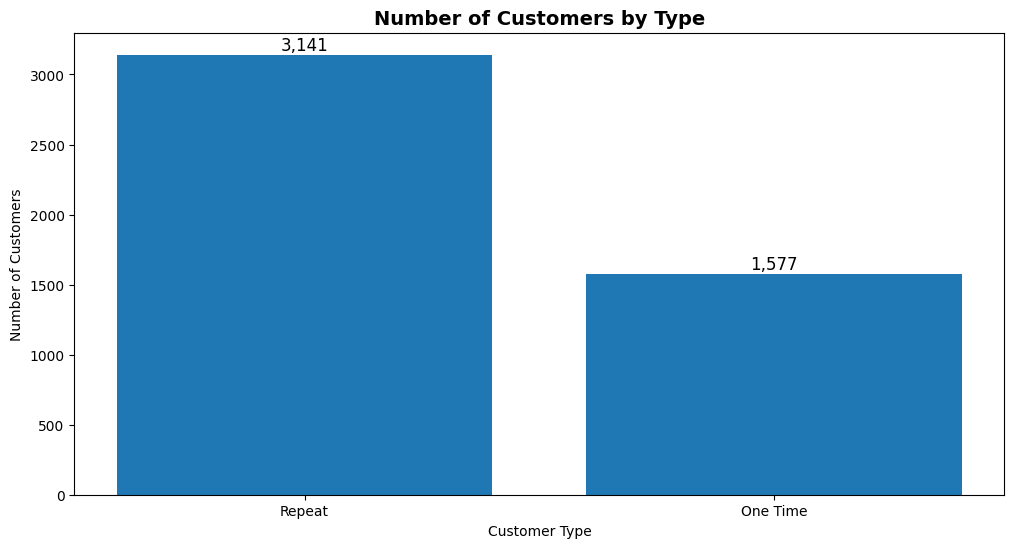

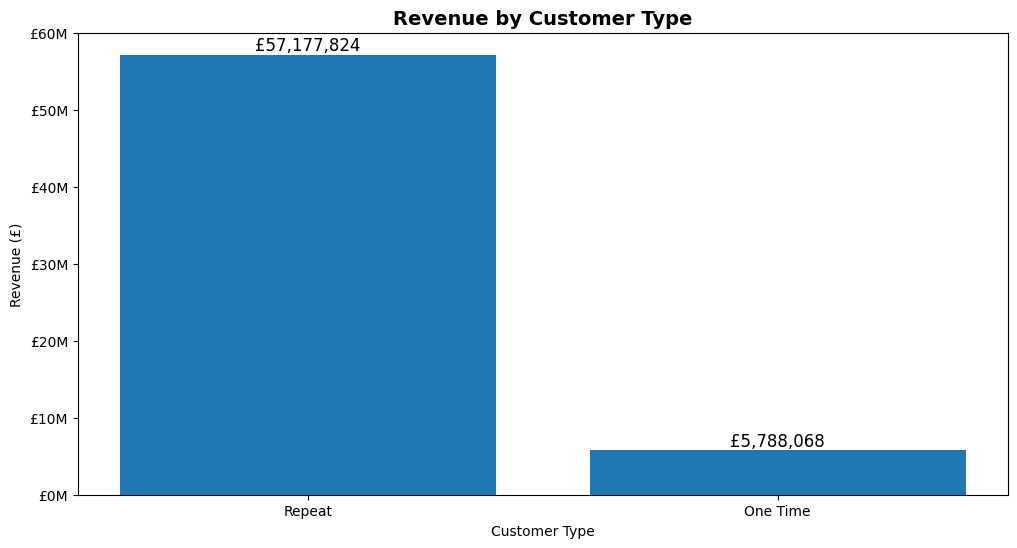

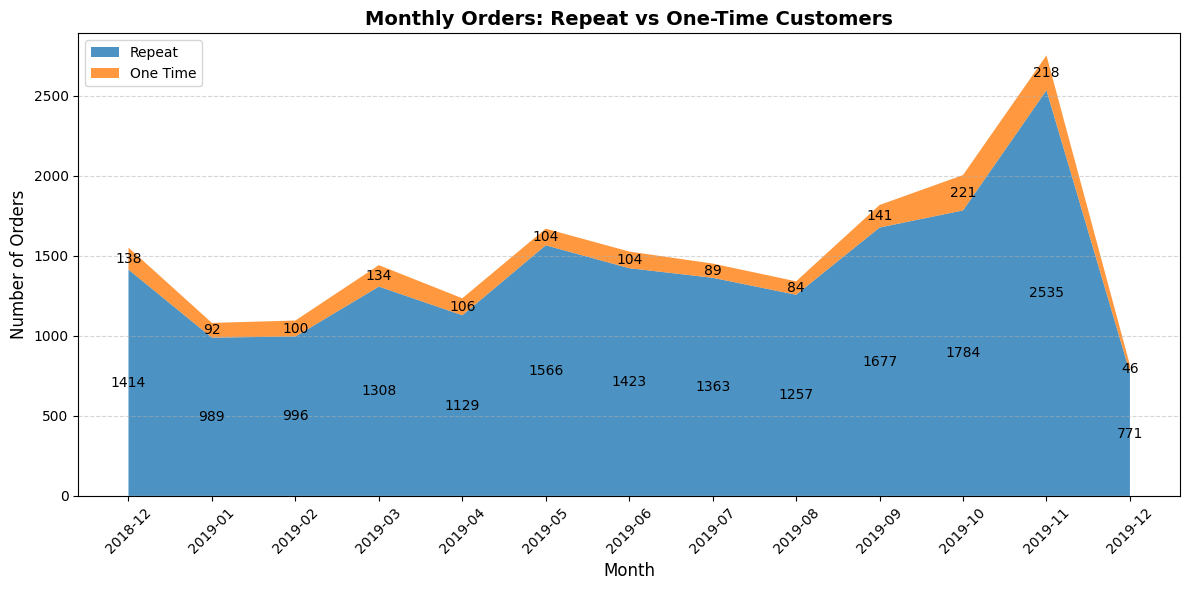

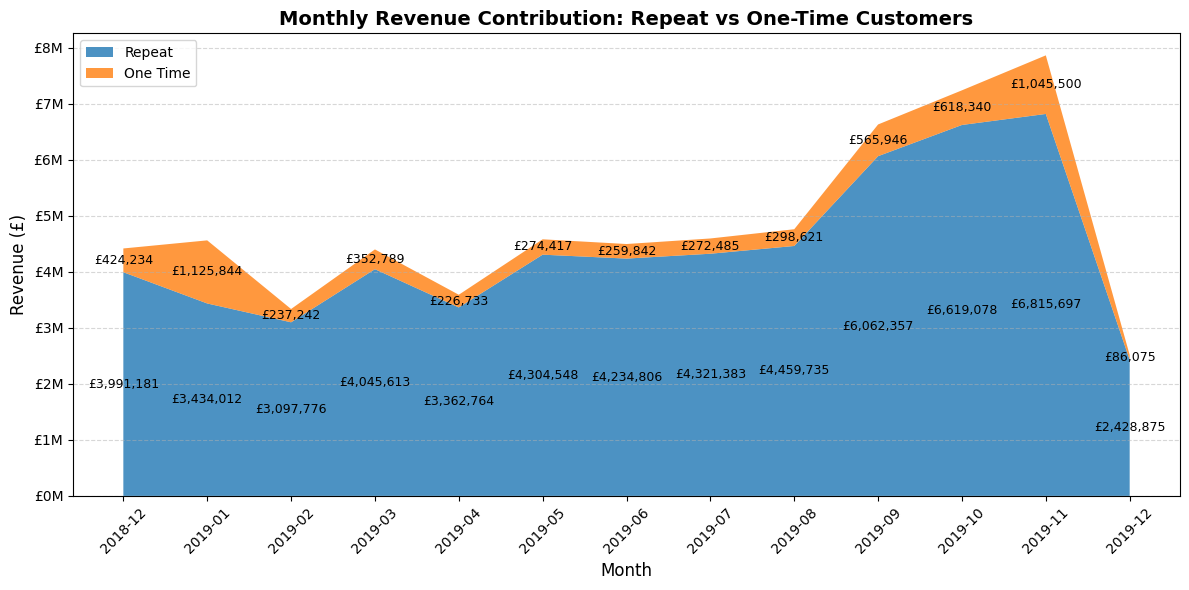

In [20]:
# Step 4: Repeat Customer & Retention Analysis

# Step 4a: Count Purchases per Customer
# Number of transactions per customer
purchase_count = df_valid.groupby('CustomerNo')['TransactionNo'].nunique().reset_index()
purchase_count = purchase_count.rename(columns={'TransactionNo':'Transaction_Count'})

# Step 4b: Classify Repeat vs One-Time Customers
purchase_count['Customer_Type'] = purchase_count['Transaction_Count'].apply(lambda x: 'Repeat' if x > 1 else 'One Time')

# Step 4c: Repeat Customer Ratio
repeat_ratio = purchase_count['Customer_Type'].value_counts(normalize=True) * 100
display("Repeat Customer Ratio (%):")
display(repeat_ratio.round(2))

# Step 4d: Revenue by Customer Type
# Merge customer type into main dataset
df_with_type = df_valid.merge(purchase_count[['CustomerNo', 'Customer_Type', 'Transaction_Count']], on='CustomerNo')

# Revenue per row
revenue_by_type = df_with_type.groupby('Customer_Type')['Revenue'].sum().reset_index()
display(revenue_by_type)

customer_type_counts = purchase_count['Customer_Type'].value_counts().reset_index()
customer_type_counts.columns = ['Customer_Type', 'Customer_Count']
display(customer_type_counts)

# Step 4e: Monthly Revenue & Total Orders by Customer Type
# Create a new (month) column for Year-Month
df_with_type['YearMonth'] = df_with_type['Date'].dt.to_period('M')

# Monthly Revenue Contribution by Customer Type
monthly_revenue_type = df_with_type.groupby(['YearMonth', 'Customer_Type'])['Revenue'].sum().unstack()
monthly_revenue_type = monthly_revenue_type.rename(columns={'Repeat':'Repeat_Customers_Revenue',
                                                            'One Time':'One_Time_Customers_Revenue'})
display(monthly_revenue_type)

# Total Orders per Month by Customer Type
monthly_orders = df_with_type.groupby(['YearMonth', 'Customer_Type'])['TransactionNo'].nunique().reset_index()
monthly_orders = monthly_orders.rename(columns={'TransactionNo':'Total_Orders'})

monthly_orders_pivot = monthly_orders.pivot(index='YearMonth',
                                            columns='Customer_Type',
                                            values='Total_Orders').reset_index()

# Rename columns
monthly_orders_pivot.columns.name= None
monthly_orders_pivot = monthly_orders_pivot.rename(columns={'Repeat':'Repeat_Customers_Orders', 'One Time':'One_Time_Customers_Orders'})

# Add Total_Orders column
monthly_orders_pivot['Total_Orders'] = monthly_orders_pivot['Repeat_Customers_Orders'] + monthly_orders_pivot['One_Time_Customers_Orders']
display(monthly_orders_pivot)

# Step 4f: Visualizations
# Chart 1: Number of Customers by Type
order = ['Repeat', 'One Time']

plt.figure(figsize=(12,6))
bars = plt.bar(customer_type_counts.set_index('Customer_Type').loc[order].index,
               customer_type_counts.set_index('Customer_Type').loc[order]['Customer_Count'])

# Add numbers on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             height, f'{height:,.0f}', 
             ha='center', 
             va='bottom', 
             fontsize=12)

plt.title('Number of Customers by Type', fontsize=14, weight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.grid(False)

plt.savefig(os.path.join(assets_folder,'number_of_customers_by_type.png'), dpi=300)
plt.show()

# Chart 2: Revenue by Customer Type
order = ['Repeat', 'One Time']

plt.figure(figsize=(12,6))
bars = plt.bar(revenue_by_type.set_index('Customer_Type').loc[order].index, 
               revenue_by_type.set_index('Customer_Type').loc[order]['Revenue'])

# Add numbers on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height, f'£{height:,.0f}', 
             ha='center', 
             va='bottom', 
             fontsize=12)
    
# Format Y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{int(x/1_000_000)}M'))
    
plt.title('Revenue by Customer Type', fontsize=14, weight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Revenue (£)')
plt.grid(False)

plt.savefig(os.path.join(assets_folder,'revenue_by_customer_type.png'), dpi=300)
plt.show()

# Chart 3: Monthly Orders: Repeat vs One-Time Customers
fig, ax = plt.subplots(figsize=(12,6))

# Plot stacked area chart
ax.stackplot(
    monthly_orders_pivot['YearMonth'].astype(str),
    monthly_orders_pivot['Repeat_Customers_Orders'],
    monthly_orders_pivot['One_Time_Customers_Orders'],
    labels=['Repeat', 'One Time'],
    colors=['tab:blue', 'tab:orange'],
    alpha=0.8
)

# Add labels on each
for i, row in monthly_orders_pivot.iterrows():
    # Repeat customers
    ax.text(
        str(row['YearMonth']),
        row['Repeat_Customers_Orders']/2,  # middle of segment
        f"{row['Repeat_Customers_Orders']}",
        ha='center', va='center', fontsize=10, color='black'
    )
    # One-Time customers
    ax.text(
        str(row['YearMonth']),
        row['Repeat_Customers_Orders'] + row['One_Time_Customers_Orders']/2,  # middle of segment
        f"{row['One_Time_Customers_Orders']}",
        ha='center', va='center', fontsize=10, color='black'
    )

ax.set_title('Monthly Orders: Repeat vs One-Time Customers', fontsize=14, weight='bold')
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_xticks(range(len(monthly_orders_pivot['YearMonth'])))
ax.set_xticklabels(monthly_orders_pivot['YearMonth'].astype(str), rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(assets_folder,'monthly_orders_repeat_one_time.png'), dpi=300)
plt.show()

# Chart 4: Monthly Revenue Contribution: Repeat vs One-Time Customers
fig, ax = plt.subplots(figsize=(12,6))

# Plot stacked area chart
ax.stackplot(
    monthly_revenue_type.index.astype(str),
    monthly_revenue_type['Repeat_Customers_Revenue'],
    monthly_revenue_type['One_Time_Customers_Revenue'],
    labels=['Repeat', 'One Time'],
    colors=['tab:blue', 'tab:orange'],
    alpha=0.8
)

# Add labels on each
for i, row in monthly_revenue_type.iterrows():
    # Repeat customers
    ax.text(
        str(row.name),
        row['Repeat_Customers_Revenue']/2,
        f"£{row['Repeat_Customers_Revenue']:,.0f}",
        ha='center', va='center', fontsize=9, color='black'
    )
    # One-Time customers
    ax.text(
        str(row.name),
        row['Repeat_Customers_Revenue'] + row['One_Time_Customers_Revenue']/2,
        f"£{row['One_Time_Customers_Revenue']:,.0f}",
        ha='center', va='center', fontsize=9, color='black'
    )

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{int(x/1_000_000)}M'))

ax.set_title('Monthly Revenue Contribution: Repeat vs One-Time Customers', fontsize=14, weight='bold')
ax.set_ylabel('Revenue (£)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_xticks(range(len(monthly_revenue_type.index)))
ax.set_xticklabels(monthly_revenue_type.index.astype(str), rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(assets_folder,'monthly_revenue_contribution_repeat_one_time.png'), dpi=300)
plt.show()

# -------------------
# Export CSV for Power BI

# Table 1: Number of customers by type
data_output_path = os.path.join(data_output_folder, 'customer_counts_by_type.csv')
customer_type_counts.to_csv(data_output_path, index=False)

# Table 2: Revenue by customer type
data_output_path = os.path.join(data_output_folder, 'revenue_by_customer_type.csv')
revenue_by_type.to_csv(data_output_path, index=False)

### Overview
This analysis evaluates customer retention by distinguishing one-time vs repeat customers. It examines customer distribution, revenue contribution, and trends over time to understand loyalty patterns and revenue contribution.

### Key Observations
- **Repeat customers** represents ~66.6% of all customers, while one-time customers account for ~33.4%/
- Repeat customers generate the **majority of revenue** (£57.2M) compared to one-time customers (£5.8M).
- Monthly order trends show repeat customers consistently dominate monthly transaction volumes, with peaks in November and December.
- One-time customers have smaller contributions and more sporadic purchase patterns.

### Business Interpretation
- **Repeat customers drive the bulk of revenue**, emphasizing the importance of retention and loyalty strategies.
- One-time customers present a **growth opportunity** if they can be converted to repeat buyers.
- Seasonal peaks (Nov_Dec) suggest holiday-driven behavior, which could be leveraged for targeted campaigns.
- Tracking **repeat purchase trends monthly** helps identify retention improvement or declines.

### Key Risks Identified
- Heavy reliance on repeat customers increases **risk if high_value repeat customers churn**.
- One-time customers may indicate **poor onboarding**, low **satisfaction**, or **missed engagement opportunities**.
- Revenue concentration in repeat customers may mask potential losses if acquisition of new customers slows down.

### Key Opportunities Identified
- Develop **targeted re-engagement campaigns** to convert one-time customers to repeat buyers.
- Reward and incentivize repeat customers through **loyalty programs** and **exlusive offers**.
- Align **marketing and operational planning** with monthly order trends to maximize high_volume periods.
- Use **customer-type segmentation** for personalized recommendations, cross-sell, or bundle promotions.



## Step 5 — Monthly Sales Trend Analysis
---

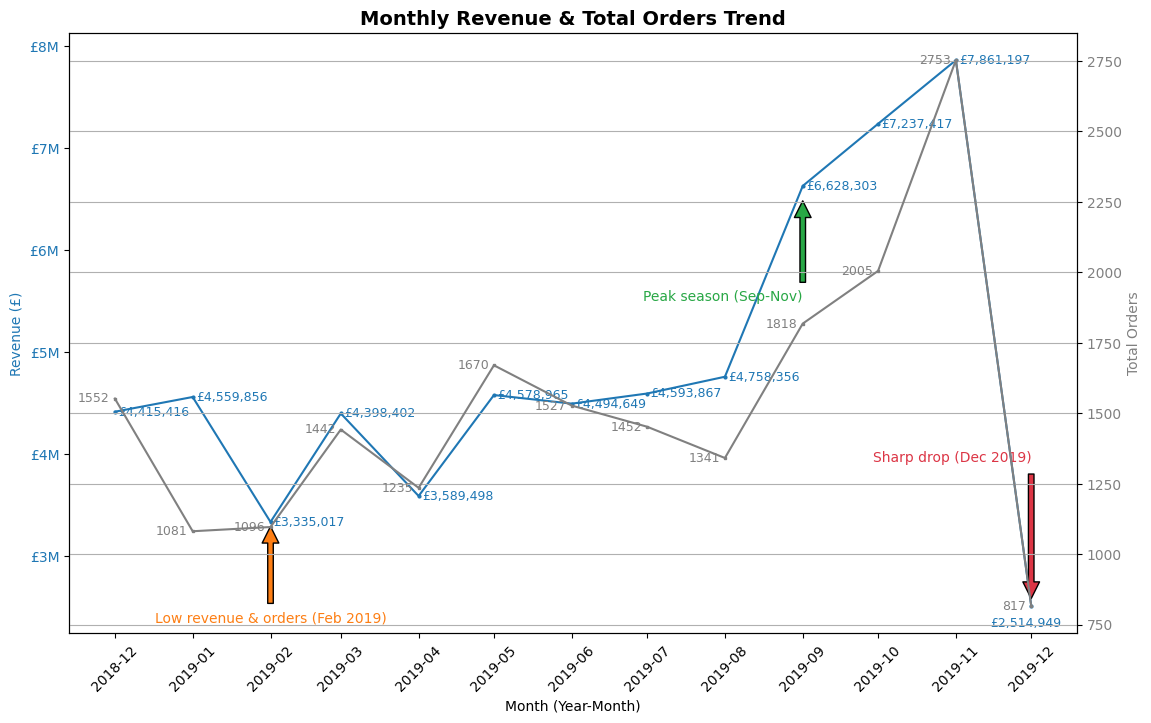

,YearMonth,Revenue,Total_Orders,YearMonth_dt
0,2018-12,4415415.52,1552,2018-12-01
1,2019-01,4559856.37,1081,2019-01-01
2,2019-02,3335017.18,1096,2019-02-01
3,2019-03,4398401.60,1442,2019-03-01
4,2019-04,3589497.88,1235,2019-04-01
5,2019-05,4578965.08,1670,2019-05-01
6,2019-06,4494648.81,1527,2019-06-01
7,2019-07,4593867.06,1452,2019-07-01
8,2019-08,4758356.02,1341,2019-08-01
9,2019-09,6628303.06,1818,2019-09-01


In [21]:
# Step 5: Monthly Sales Trend Analysis

# Step 5a: Aggregate Revenue by Month
monthly_revenue = df_with_type.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['Revenue'] = monthly_revenue['Revenue'].round(2)

# Merge monthly revenue and total orders per month
monthly_metrics = pd.merge(monthly_revenue,
                           monthly_orders_pivot[['YearMonth', 'Total_Orders']],
                           on='YearMonth')

# Step 5b: Plot Monthly Revenue Trend

# Convert YearMonth (Period) to datetime (first day of month)
monthly_metrics['YearMonth_dt'] = monthly_metrics['YearMonth'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12,8))

x = monthly_metrics['YearMonth_dt'] # datetime for x-axis

# Plot Revenue on primary y-axis
ax1.plot(x, monthly_metrics['Revenue'], color='#1f77b4', marker='o', markersize=2, label='Revenue')
ax1.set_xlabel('Month (Year-Month)')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_metrics['YearMonth'].astype(str), rotation=45, fontsize=10)
ax1.set_ylabel('Revenue (£)', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{int(x/1_000_000)}M'))

# Add labels on each Revenue point
for i, (xi, y) in enumerate(zip(x, monthly_metrics['Revenue'])):
    # Default label position
    y_label = y
    x_label = xi + pd.Timedelta(days=15.5)

    # For adjusting last month
    if i == len(x) -1:
        y_label = y - 170_000  # y axis
        x_label = xi - pd.Timedelta(days=2)  # x axis
    
    ax1.text(
        x_label,
        y_label,
        f'£{y:,.0f}',
        ha='center',
        va='center',
        fontsize=9,
        color='#1f77b4'
    )

# Plot Total Orders on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x, monthly_metrics['Total_Orders'], color='#808080', marker='s', markersize=2, label='Total Orders')
ax2.set_ylabel('Total Orders', color='#808080')
ax2.tick_params(axis='y', labelcolor='#808080')

# Add labels on each Total Orders point
for xi, y_val in zip(x, monthly_metrics['Total_Orders']):
    ax2.text(
        xi - pd.Timedelta(days=2),
        y_val, f'{y_val}',
        ha='right', 
        va='center', 
        fontsize=9, 
        color='#808080'
    )

# Annotations
# February 2019 dip
ax1.annotate('Low revenue & orders (Feb 2019)',
             xy=(x[2], monthly_metrics['Revenue'][2]),
             xytext=(x[2], monthly_metrics['Revenue'].max()*0.30),
             arrowprops=dict(facecolor='#fd7e14', shrink=0.05),
             fontsize=10, color='#fd7e14',
             ha='center')

# Sept-Nov peak
ax1.annotate('Peak season (Sep-Nov)',
             xy=(x[9], monthly_metrics['Revenue'][9] - 100_000),
             xytext=(x[9], monthly_metrics['Revenue'].max()*0.70),
             arrowprops=dict(facecolor='#28a745', shrink=0.05),
             fontsize=10, color='#28a745',
             ha='right')
                

# December drop
ax1.annotate('Sharp drop (Dec 2019)',
             xy=(x[12], monthly_metrics['Revenue'][12]),
             xytext=(x[12], monthly_metrics['Revenue'].max()*0.5),
             arrowprops=dict(facecolor='#dc3545', shrink=0.05),
             fontsize=10, color='#dc3545',
             ha='right')

plt.title('Monthly Revenue & Total Orders Trend', fontsize=14, weight='bold')
plt.subplots_adjust(top=0.9, bottom=0.15, left=0.08, right=0.92)
plt.grid(True)

plt.savefig(os.path.join(assets_folder,'monthly_revenue_total_orders_trend.png'), dpi=300)
plt.show()

# -------------------
# Quick check
display(monthly_metrics)

# Export CSV for Power BI
data_output_path = os.path.join(data_output_folder, 'monthly_metrics.csv')
monthly_metrics.to_csv(data_output_path, index=False)

### Overview
This analysis examines monthly revenue and total orders trends from December 2018 to December 2019 to understand revenue stability, seasonality, and potential business risks.

### Key Observations
- Revenue and order increased slightly from **December 2018 to January 2019**, indicating a stable start to the year.
- A **significant dip for both revenue and total orders in February 2019** suggests post-holiday slowdown or reduced customer demand.
- Revenue and orders partially recovered in **March 2019**, followed by another decline in **April 2019**, showing early-year volatility and fluctuations.
- From **May to August 2019**, both revenue and orders remained relatively stable, indicating a consolidation period without strong growth.
- A **strong upward trend in revenue and total orders from September to November 2019** highlights peak-season demand, likely driven by seasonal shopping and promotional campaigns.
- A **sharp decline in December 2019** for revenue and orders represents a potential concern, possibly caused by inventory shortages, reduced promotions, incomplete December data.

### Business Interpretation
- The business experiences **clear seasonality**, with strong performance in Q4 and weaker performance in early-year months.
- Revenue and order volatility in the first half of the year may create **cash flow uncertainty** and complicate operational and inventory planning.


### Key Risk Identified
- Overdependence on peak months (September-November) exposes the business to **risk exposure** and **revenue shocks** if supply chain, forecasts, promotions or demand predictions are inaccurate.
- Weak performance in early year increases the risk of excess inventory and higher holding costs.

### Key Opportunities Identified
- **Stabilize during low-performing months** through targeted promotions, customer retention campaigns, or product bundling.
- Using historical seasonality patterns to improve inventory planning and marketing timing.
- Analyze **order volume vs revenue trends** to optimize promotions and maximize revenue per transaction.

## Step 6 — Product Performance Analysis
---

,ProductName,Revenue
0,Paper Craft Little Birdie,1002718.10
1,Medium Ceramic Top Storage Jar,881990.18
2,Popcorn Holder,587433.94
3,World War 2 Gliders Asstd Designs,569735.39
4,Cream Hanging Heart T-Light Holder,484592.69
...,...,...
3748,Funky Monkey Mug,11.53
3749,Pink Crystal Guitar Phone Charm,11.12
3750,Hen House W Chick In Nest,10.68
3751,Set 10 Cards Snowy Robin 17099,6.19


,ProductName,Quantity
0,Paper Craft Little Birdie,80995
1,Medium Ceramic Top Storage Jar,78033
2,Popcorn Holder,56921
3,World War 2 Gliders Asstd Designs,55047
4,Jumbo Bag Red Retrospot,48478
...,...,...
3748,Set 10 Cards Triangle Icons 17220,1
3749,Orange/Fuschia Stones Necklace,1
3750,Pack 4 Flower/Butterfly Patches,1
3751,Crochet Lilac/Red Bear Keyring,1


,ProductName,Revenue,Quantity,Segment
0,Paper Craft Little Birdie,1002718.10,80995,High Performer
1,Medium Ceramic Top Storage Jar,881990.18,78033,High Performer
2,Popcorn Holder,587433.94,56921,High Performer
3,World War 2 Gliders Asstd Designs,569735.39,55047,High Performer
4,Cream Hanging Heart T-Light Holder,484592.69,37956,High Performer
...,...,...,...,...
3748,Funky Monkey Mug,11.53,1,Low Performer
3749,Pink Crystal Guitar Phone Charm,11.12,1,Low Performer
3750,Hen House W Chick In Nest,10.68,1,Low Performer
3751,Set 10 Cards Snowy Robin 17099,6.19,1,Low Performer


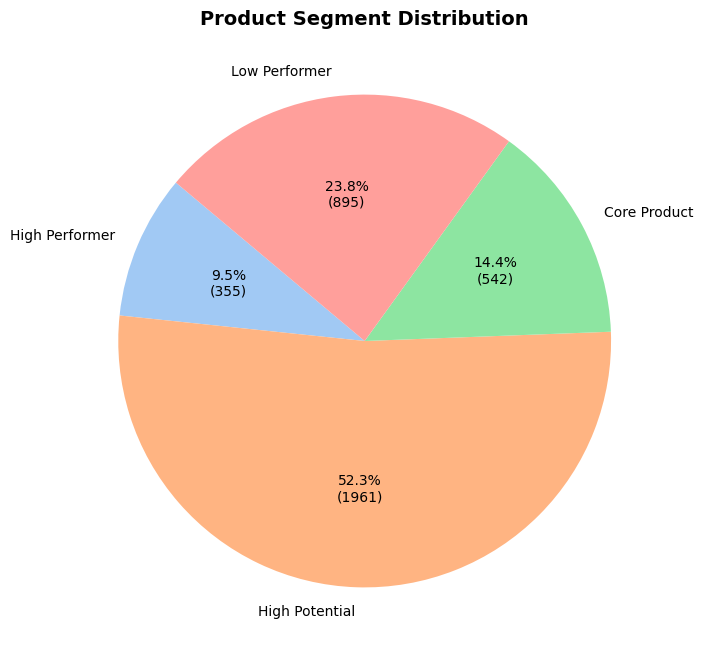

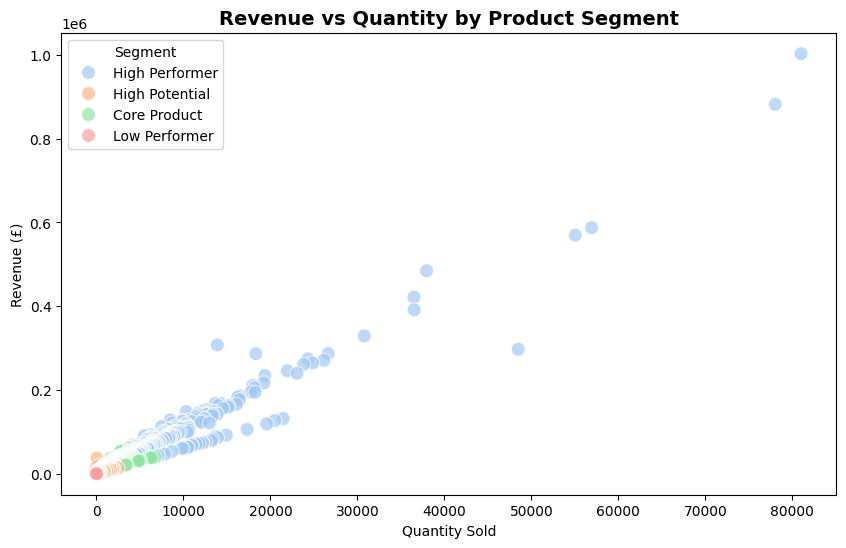

In [22]:
# Step 6: Product Performance Analysis

# Step 6a: Total Revenue per Product
product_revenue = df_valid.groupby('ProductName')['Revenue'].sum().reset_index()
product_revenue = product_revenue.sort_values(by='Revenue', ascending=False)
product_revenue['Revenue'] = product_revenue['Revenue'].round(2)

# Step 6b: Total Quantity Sold per Product
product_quantity = df_valid.groupby('ProductName')['Quantity'].sum().reset_index()
product_quantity = product_quantity.sort_values(by='Quantity', ascending=False)

# Step 6c: Product Segmentation (Revenue vs Quantity)
# Merge revenue and quantity
product_metrics = pd.merge(product_revenue, product_quantity, on='ProductName')

# Quantiles for segmentation
rev_90 = product_metrics['Revenue'].quantile(0.90)
qty_90 = product_metrics['Quantity'].quantile(0.90)
rev_75 = product_metrics['Revenue'].quantile(0.75)
rev_25 = product_metrics['Revenue'].quantile(0.25)
qty_75 = product_metrics['Quantity'].quantile(0.75)
qty_25 = product_metrics['Quantity'].quantile(0.25)

# Segment products based on thresholds
def segment_product(row):
    if row['Revenue'] >= rev_90 and row['Quantity'] >= qty_90:
        return 'High Performer'
    elif row['Revenue'] >= rev_75 and row['Quantity'] >= qty_75:
        return 'Core Product'
    elif row['Revenue'] < rev_25 and row['Quantity'] < qty_25:
        return 'Low Performer'
    else:
        return 'High Potential'

product_metrics['Segment'] = product_metrics.apply(segment_product, axis=1)

# Step 6d: Top 10 Products by Revenue

# Show top 10 products by revenue
#top10_products_revenue = product_revenue.head(10)
##print("Top 10_Products by_Revenue:")
##print(top10_products_revenue)

top10_products_revenue = (
    product_revenue
    .sort_values(by='Revenue', ascending=False)
    .reset_index(drop=True)
)
display(top10_products_revenue)

# Step 6e: Top 10 Products by Quantity Sold

# Show top 10 products by quantity sold
#top10_products_quantity = product_quantity.head(10)
#print("\nTop 10 Products by Quantity Sold:")
#print(top10_products_quantity)

top10_products_quantity = (
    product_quantity
    .sort_values(by='Quantity', ascending=False)
    .reset_index(drop=True)
)
display(top10_products_quantity)

# Step 6f: Sort product metrics for portfolio
segment_order = ['High Performer', 'High Potential', 'Core Product', 'Low Performer']
product_metrics['Segment'] = pd.Categorical(product_metrics['Segment'], categories=segment_order, ordered=True)

product_metrics_sorted = product_metrics.sort_values(['Segment', 'Revenue'], ascending=[True, False]).reset_index(drop=True)
display(product_metrics_sorted)

# Step 6g: Visualization

# Pie Chart - Product Segment Distribution
# Count of products per segment
segment_counts = product_metrics['Segment'].value_counts()
segment_counts = segment_counts.reindex(segment_order)

plt.figure(figsize=(8,8))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        absolute = int(round(pct/100.*total))
        return f"{pct:.1f}%\n({absolute})"
    return my_autopct

plt.pie(
    segment_counts.values, 
    labels=segment_counts.index, 
    autopct=make_autopct(segment_counts.values),
    startangle=140,
    colors=sns.color_palette('pastel', n_colors=len(segment_counts)))

plt.title('Product Segment Distribution', fontsize=14, weight='bold')

plt.savefig(os.path.join(assets_folder,'product_segment_distribution.png'), dpi=300)
plt.show()

# Scatter Plot - Revenue vs Quantity with Segments
plt.figure(figsize=(10,6))
sns.scatterplot(data=product_metrics, x='Quantity', y='Revenue', hue='Segment', palette='pastel', s=100, alpha=0.7)
plt.title('Revenue vs Quantity by Product Segment', fontsize=14, weight='bold')
plt.xlabel('Quantity Sold')
plt.ylabel('Revenue (£)')
plt.legend(title='Segment')

plt.savefig(os.path.join(assets_folder,'revenue_vs_quantity_by_segment.png'), dpi=300)
plt.show()

# Step 6i: Rank Columns
product_metrics_sorted['Revenue_Rank'] = product_metrics_sorted['Revenue'].rank(ascending=False)
product_metrics_sorted['Quantity_Rank'] = product_metrics_sorted['Quantity'].rank(ascending=False)

# -------------------
# Export CSVs for Power BI

# Top 10 products by revenue
data_output_path = os.path.join(data_output_folder, 'top10_products_revenue.csv')
top10_products_revenue.head(10).to_csv(data_output_path, index=False)

# Top 10 products by quantity sold
data_output_path = os.path.join(data_output_folder, 'top10_products_quantity.csv')
top10_products_quantity.head(10).to_csv(data_output_path, index=False)

# Product metrics with segments
data_output_path = os.path.join(data_output_folder, 'product_metrics.csv')
product_metrics_sorted.to_csv(data_output_path, index=False)

### Overview
This step analyzes product-level revenue and sales volume to identify top-performing, moderate, high-potential, and low-performing products. Segmentation helps prioritize inventory, marketing and promotional efforts.

### Key Observations
- **Top-performing products** generate the highest revenue and sales volume.
- High Performers dominate both revenue and quantity sold, indicating strong market demand.
- **Top 5 High Performer by Revenue:**
    1. Paper Craft Little Birdie – £1,002,718
    2. Medium Ceramic Top Storage Jar – £881,990
    3. Popcorn Holder – £587,434
    4. World War 2 Gliders Asstd Designs – £569,735
    5. Cream Hanging Heart T-Light Holder – £484,593
- **Top 5 High Performer by Quantity Sold:**
    1. Paper Craft Little Birdie – 80,995 units
    2. Medium Ceramic Top Storage Jar – 78,033 units
    3. Popcorn Holder – 56,921 units
    4. World War 2 Gliders Asstd Designs – 55,047 units
    5. Jumbo Bag Red Retrospot – 48,478 units 
- Product segmentation shows:
    - **High Performer**: High revenue and high sales volume
    - **Core Product**: Mid-range revenue and quantity sold
    - **High Potential**: Mixed performance - good revenue or good quantity, but not both
    - **Low Performer**: Low revenue and low quantity

### Business Interpretation
- **High Performer**: Maintain stock, prioritize marketing, consider bundling to maximize revenue.
- **Core Product**: Monitor trends and run targeted promotions to improve sales.
- **High Potential**: Focus on marketing or product improvements to convert into High Performers.
- **Low Performer**: Evaluate inventory strategy, consider discontinuation or clearance campaigns.
- Product performance aligns with customer purchasing behavior and seasonal trends, guiding inventory and marketing decisions.

### Key Risks Identified
- Over-reliance on High Performer products could create revenue vulnerability if demand shifts.
- Low Performer products may tie up inventory and increase storage costs.

### Key Opportunities Identified
- Expand marketing campaigns for High Performer products to boost revenue further.
- Promote Core and High Potential products using cross-sells or bundling to improve sales mix.
- Monitor Low Performer products to reduce operational costs or repackage for niche markets.

## Step 7 — Business Recommendations
---

Based on the insights from customer behavior, RFM segmentation, monthly sales trends, retention analysis and product performance, the following actions are recommended:
1.  **Prioritize retention of high-value customers**
    - High-value and VIP/VeryHighValue customers contribute a disproportionate share of revenue.
    - Implement loyalty programs, personalized offers, and early-access campaigns to retain this customers, protect predictable revenue and possibly increase customer lifetime value.

2.  **Plan inventory and marketing around seasonal demand**
    - Monthly sales trends show strong and really depends on seasonality with the most peak demand is on Q4. - Start marketing campaigns by August and coordinate production teams to ensure sufficient inventory so it can reduce stockouts and missed sales opportunities.

3.  **Convert one-time customers into repeat buyers**
    - Repeat customers (66.6%) generate the majority of revenue (90%).
    - Offer targeted incentives for second purchases or repeat orders will contribute huge increase on revenue, leveraging existing customers rather than acquiring new ones at higher costs.

4.  **Reactivate at-risk and churned customers**
    - Deploy tailored reactivation campaigns, personalized promotions, or product recommendations to encourage repeat purchases and prevent further revenue loss. 
    
5.  **Optimize product strategy using performance segmentation**
    - High Performer products should be prioritized for production, inventory and marketing.
    - Use bundling, cross-selling or promotional strategies to increase sales of Moderate products.
    - Low Performers products should be evaluated for clearance, repackaging or niche targeting to reduce holding costs.

## Step 8 — Limitations & Next Steps
---

## Limitations
1.  This analysis is based solely on Dec 2018 - Dec 2019 transaction data and does not include with more details on customers or marketing channel.
2.  Customer behavior is analyzed from past transactions and it not predict future customer purchasing behavior.
3.  External factors such as promotions, supply chain issues, or ambient economic conditions are not been told in the dataset.
4.  The sharp decrease in Dec 2019 revenue may be influenced by inadequate data information or operational factors that cannot be confirmed solely
    from this dataset alone. Could be many things that influenced the decrease revenue.

## Next Steps
1.  Develop an interactive POWER BI dashboard to visualize key metrics such as customer metrics, monthly revenue trends, customer retention churned,
    and top-performing products for stakeholders and production department.
2.  Perform cohort-based retention analysis for better understand on long-term customer behavior over time.
3.  Using SQL to replicate key analyses to improve scalability and align with real-world data environments.
4.  Gather more data and details about the customers including marketing channel and campaign data to enhance segmentation and targetting
    strategies to avoid wasting.
5.  Future work could include revenue forecasting using Prophet or ARIMA.
6. Automate data cleaning, processing, and reporting using Google Apps Script so insights and dashboards can be updated automatically, saving time and reducing manual work.